In [ ]:
'''
Consider a dataset containing records related to customer purchasing 
behavior. The dataset includes multiple numerical features describing 
customer demographics and spending patterns.The program should perform 
the following tasks:
i. Read the given dataset into a dataframe.
ii. Perform necessary data preprocessing and feature scaling.
iii. Apply the K-Means Clustering algorithm on the dataset for different 
values of K.
iv. Determine the optimal number of clusters using the Elbow Method.
v. Validate the clustering results using the Silhouette Score.
vi. Perform clustering using the optimal value of K and assign cluster labels 
to the data points.
vii. Visualize the formed clusters and analyze the clustering results.
'''

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
df=pd.DataFrame({
    'Age':np.array([19, 21, 20, 23, 31, 22, 35, 23, 64, 30]),
    'Income':np.array([15, 16, 17, 18, 19, 20, 21, 22, 23, 24]),
    'Spending':np.array([39, 81, 6, 77, 40, 76, 6, 94, 3, 72])
})
df

,Age,Income,Spending
0,19,15,39
1,21,16,81
2,20,17,6
3,23,18,77
4,31,19,40
5,22,20,76
6,35,21,6
7,23,22,94
8,64,23,3
9,30,24,72


In [6]:
X=df[['Age','Income','Spending']]

In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)  #fit=mean and std transform=perform standard scaler formula

In [8]:
wcs=[]
for k in range(1,7):
    model=KMeans(n_clusters=k,random_state=0)
    model.fit(X_scaled)#for centroid finding
    wcs.append(model.inertia_)#wcss finding

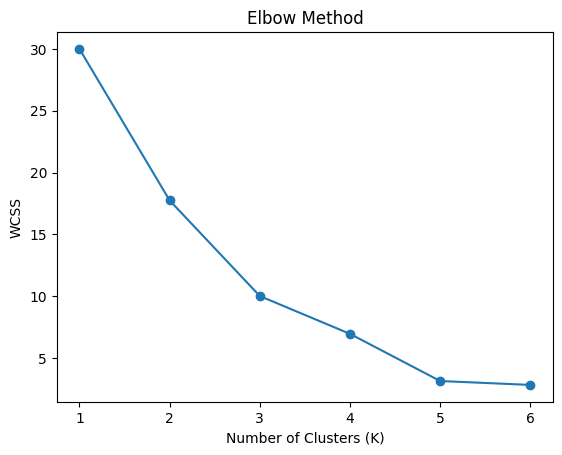

In [9]:
plt.plot(range(1,7),wcs,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [13]:
sil_sc=[]
for k in range(2,7):
    model=KMeans(n_clusters=k)
    label=model.fit_predict(X_scaled)#fit=Runs K-Means algorithm,Finds centroids;;predict= which pt belong to same or diffn cluster/Assigns each point to a cluster
    score=silhouette_score(X_scaled,label)#perform s-s formula using both distance and cluster
    sil_sc.append(score)
    print(f"Silhouette Score for K={k}: {score}")

Silhouette Score for K=2: 0.25138730970100054
Silhouette Score for K=3: 0.26516601200240997
Silhouette Score for K=4: 0.25096144085077676
Silhouette Score for K=5: 0.18231883853983993
Silhouette Score for K=6: 0.20628606629271196


In [14]:
k_opt=3#assume
model=KMeans(n_clusters=k_opt)
y_model=model.fit_predict(X_scaled)#fit=Runs K-Means algorithm,Finds centroids;;predict= which pt belong to same or diffn cluster/Assigns each point to a cluster
df['cluster']=y_model
df

,Age,Income,Spending,cluster
0,19,15,39,2
1,21,16,81,0
2,20,17,6,2
3,23,18,77,0
4,31,19,40,0
5,22,20,76,0
6,35,21,6,1
7,23,22,94,0
8,64,23,3,1
9,30,24,72,0


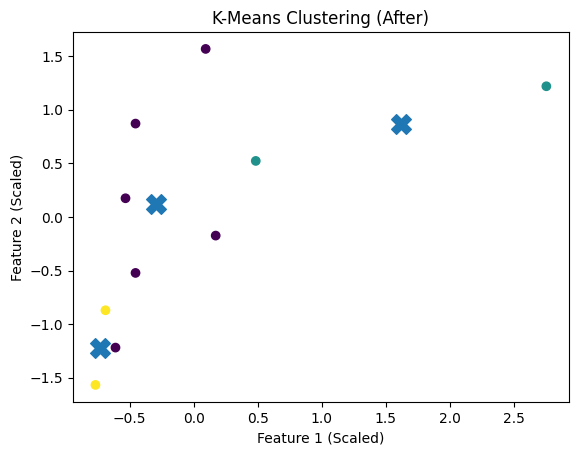

In [15]:
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y_model)#feature1 and 2 and diff color for different cluster
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],s=200, marker='X')#plot centroid
plt.title("K-Means Clustering (After)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.show()